# Round 5 Manual - Read the Story, Then Respect the Fee Curve

This notebook turns article-level move priors into a quadratic-fee portfolio. The hard part in the round was not only calling direction. It was sizing without letting the fee curve punish us for overconfidence.

The final book defended here is the more measured portfolio led by the Lava short, not the more aggressive hype-chasing alternative.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

BUDGET = 1_000_000
products = [
    "Obsidian cutlery", "Pyroflex cells", "Thermalite core", "Lava cake", "Magma ink",
    "Scoria paste", "Ashes of the Phoenix", "Volcanic incense", "Sulfur reactor"
]
base_moves = np.array([-0.108, -0.187, 0.145, -0.452, 0.106, 0.081, -0.242, 0.102, 0.102])
final_alloc = np.array([-5, -9, 7, -22, 5, 4, -12, 5, 5])
rank1_shot = np.array([-5, -10, 7, -24, 6, 5, -13, 6, 5])
aggressive_hype = np.array([-8, -10, 6, -20, 7, 4, -12, 11, 4])
conservative = np.array([-4, -8, 6, -18, 4, 3, -10, 4, 4])

def portfolio_pnl(moves, alloc):
    pct = np.abs(alloc) / 100
    side = np.sign(alloc)
    gross = BUDGET * np.sum(side * moves * pct)
    fee = BUDGET * np.sum(pct ** 2)
    return gross - fee

def implied_optimal_alloc(moves):
    raw = np.rint(50 * np.abs(moves)).astype(int)
    if raw.sum() > 100:
        raw = np.floor(raw * 100 / raw.sum()).astype(int)
    return raw * np.sign(moves).astype(int)

print("%-22s %8s %8s %10s" % ("product", "move", "alloc", "one-name EV"))
for name, m, a in zip(products, base_moves, final_alloc):
    one = portfolio_pnl(np.array([m]), np.array([a]))
    print("%-22s %+7.1f%% %+7d%% %10.1f" % (name, 100*m, a, one))
print("\nFinal book expected PnL %.1f" % portfolio_pnl(base_moves, final_alloc))
print("Closed-form integer allocation from priors:", implied_optimal_alloc(base_moves).tolist())


product                    move    alloc one-name EV
Obsidian cutlery         -10.8%      -5%     2900.0
Pyroflex cells           -18.7%      -9%     8730.0
Thermalite core          +14.5%      +7%     5250.0
Lava cake                -45.2%     -22%    51040.0
Magma ink                +10.6%      +5%     2800.0
Scoria paste              +8.1%      +4%     1640.0
Ashes of the Phoenix     -24.2%     -12%    14640.0
Volcanic incense         +10.2%      +5%     2600.0
Sulfur reactor           +10.2%      +5%     2600.0

Final book expected PnL 92200.0
Closed-form integer allocation from priors: [-5, -9, 7, -23, 5, 4, -12, 5, 5]


In [2]:
rng = np.random.default_rng(7)
N = 25_000
sigma = np.array([0.055, 0.070, 0.060, 0.130, 0.080, 0.090, 0.085, 0.115, 0.055])
common = rng.normal(0, 0.025, size=(N, 1))
idiosyncratic = rng.normal(0, sigma, size=(N, len(products)))
crowd = rng.normal(0, 0.06, size=(N, 1))
crowd_load = np.array([0.2, 0.25, 0.15, -0.65, 0.55, 0.45, -0.55, 0.75, 0.15])
scenario_moves = base_moves + common + idiosyncratic + crowd * crowd_load
scenario_moves = np.where(np.sign(scenario_moves) == np.sign(base_moves), scenario_moves, 0.25 * scenario_moves)

candidates = {
    "MC mean / median": final_alloc,
    "rank1-shot": rank1_shot,
    "aggressive hype": aggressive_hype,
    "conservative": conservative,
}
print("%-18s %10s %10s %10s %10s" % ("candidate", "mean", "median", "std", "p05"))
for label, alloc in candidates.items():
    vals = np.array([portfolio_pnl(m, alloc) for m in scenario_moves])
    print("%-18s %10.1f %10.1f %10.1f %10.1f" % (label, vals.mean(), np.median(vals), vals.std(), np.percentile(vals, 5)))


candidate                mean     median        std        p05


MC mean / median      93314.9    93426.8    36444.8    33565.5


rank1-shot            93065.4    93157.3    40012.6    27402.1


aggressive hype       88788.6    88719.7    36726.6    28528.0


conservative          89547.2    89605.8    29893.9    40506.3


In [3]:
optimal_allocs = np.array([implied_optimal_alloc(m) for m in scenario_moves])
mean_abs_alloc = np.mean(np.abs(optimal_allocs), axis=0)
buy_prob = np.mean(optimal_allocs > 0, axis=0)
sell_prob = np.mean(optimal_allocs < 0, axis=0)
print("%-22s %10s %10s %10s" % ("product", "mean_abs", "buy_prob", "sell_prob"))
for name, ma, bp, sp in zip(products, mean_abs_alloc, buy_prob, sell_prob):
    print("%-22s %10.2f %10.2f %10.2f" % (name, ma, bp, sp))


product                  mean_abs   buy_prob  sell_prob
Obsidian cutlery             5.42       0.01       0.94
Pyroflex cells               9.31       0.00       0.99
Thermalite core              7.17       0.98       0.00
Lava cake                   22.40       0.00       1.00
Magma ink                    5.58       0.86       0.05
Scoria paste                 4.63       0.77       0.10
Ashes of the Phoenix        12.02       0.00       0.99
Volcanic incense             5.95       0.77       0.13
Sulfur reactor               5.12       0.93       0.01


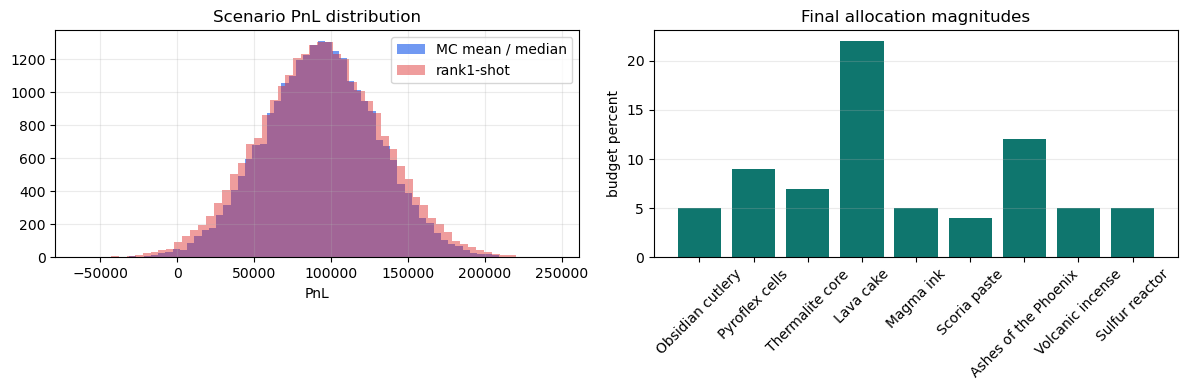

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vals_final = np.array([portfolio_pnl(m, final_alloc) for m in scenario_moves])
vals_rank1 = np.array([portfolio_pnl(m, rank1_shot) for m in scenario_moves])
axes[0].hist(vals_final, bins=60, alpha=0.65, label="MC mean / median", color="#2563eb")
axes[0].hist(vals_rank1, bins=60, alpha=0.45, label="rank1-shot", color="#dc2626")
axes[0].set_title("Scenario PnL distribution")
axes[0].set_xlabel("PnL")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].bar(products, np.abs(final_alloc), color="#0f766e")
axes[1].set_title("Final allocation magnitudes")
axes[1].set_ylabel("budget percent")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout()
